In [53]:
import numpy as np
import matplotlib.pyplot as plt
import re
import scienceplots
import itertools

# Apply the IEEE style globally before creating the figure
plt.style.use(['science', 'ieee', 'std-colors'])
ieee_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_dispenser = itertools.cycle(ieee_colors)

files = ['2026-03-13_16-22-38', '2026-03-15_01-41-29', '2026-03-16_09-10-21', '2026-03-17_11-07-09', '2026-03-18_13-58-51']
run_times = [22.08, 21.50, 20.77, 22.43, 21.25]

total_iterations = 60
all_iterations = np.arange(1, total_iterations + 1)

In [54]:
plot_area_data = []
area_lines = []

for filename in files:
    iterations = []
    areas = []

    with open(f'Algorithm Run Data/{filename}.txt', 'r', encoding='utf-8') as file:
        log_text = file.read()

    blocks = log_text.split("INFO - ")

    for block in blocks[1:]: 
        iter_match = re.search(r"Iteration (\d+)", block)
        if not iter_match:
            continue
        iteration = int(iter_match.group(1))

        area_match = re.search(r"Global Best Area:\s*([\d.]+)", block)
        area = float(area_match.group(1))

        iterations.append(iteration)
        areas.append(area)

    iterations = np.array(iterations)
    areas = np.array(areas)

    indices = np.searchsorted(iterations, all_iterations, side='right') - 1
    filled_areas = areas[indices]

    plot_area_data.append(filled_areas)

In [55]:
plot_gmid_data = []
gmid_lines = []

iterations = []
gm_id_data = [[] for _ in range(6)]

with open(f'Algorithm Run Data/{files[2]}.txt', 'r', encoding='utf-8') as file:
    log_text = file.read()

blocks = log_text.split("INFO - ")

for block in blocks[1:]:
    iter_match = re.search(r"Iteration (\d+)", block)
    if not iter_match:
        continue
    iteration = int(iter_match.group(1))

    particle_match = re.search(r"Particle\s*:\s*\[(.*?)\]", block)
    if particle_match:
        particle_str = particle_match.group(1)
        particle_values = [float(val.strip()) for val in particle_str.split(',')]
        
        iterations.append(iteration)
        
        for i in range(6):
            gm_id_data[i].append(particle_values[i])

iterations = np.array(iterations)

for i in range(6):
    gm_id_data[i] = np.array(gm_id_data[i])
    indices = np.searchsorted(iterations, all_iterations, side='right') - 1
    filled_gmids = gm_id_data[i][indices]
    plot_gmid_data.append(filled_gmids)

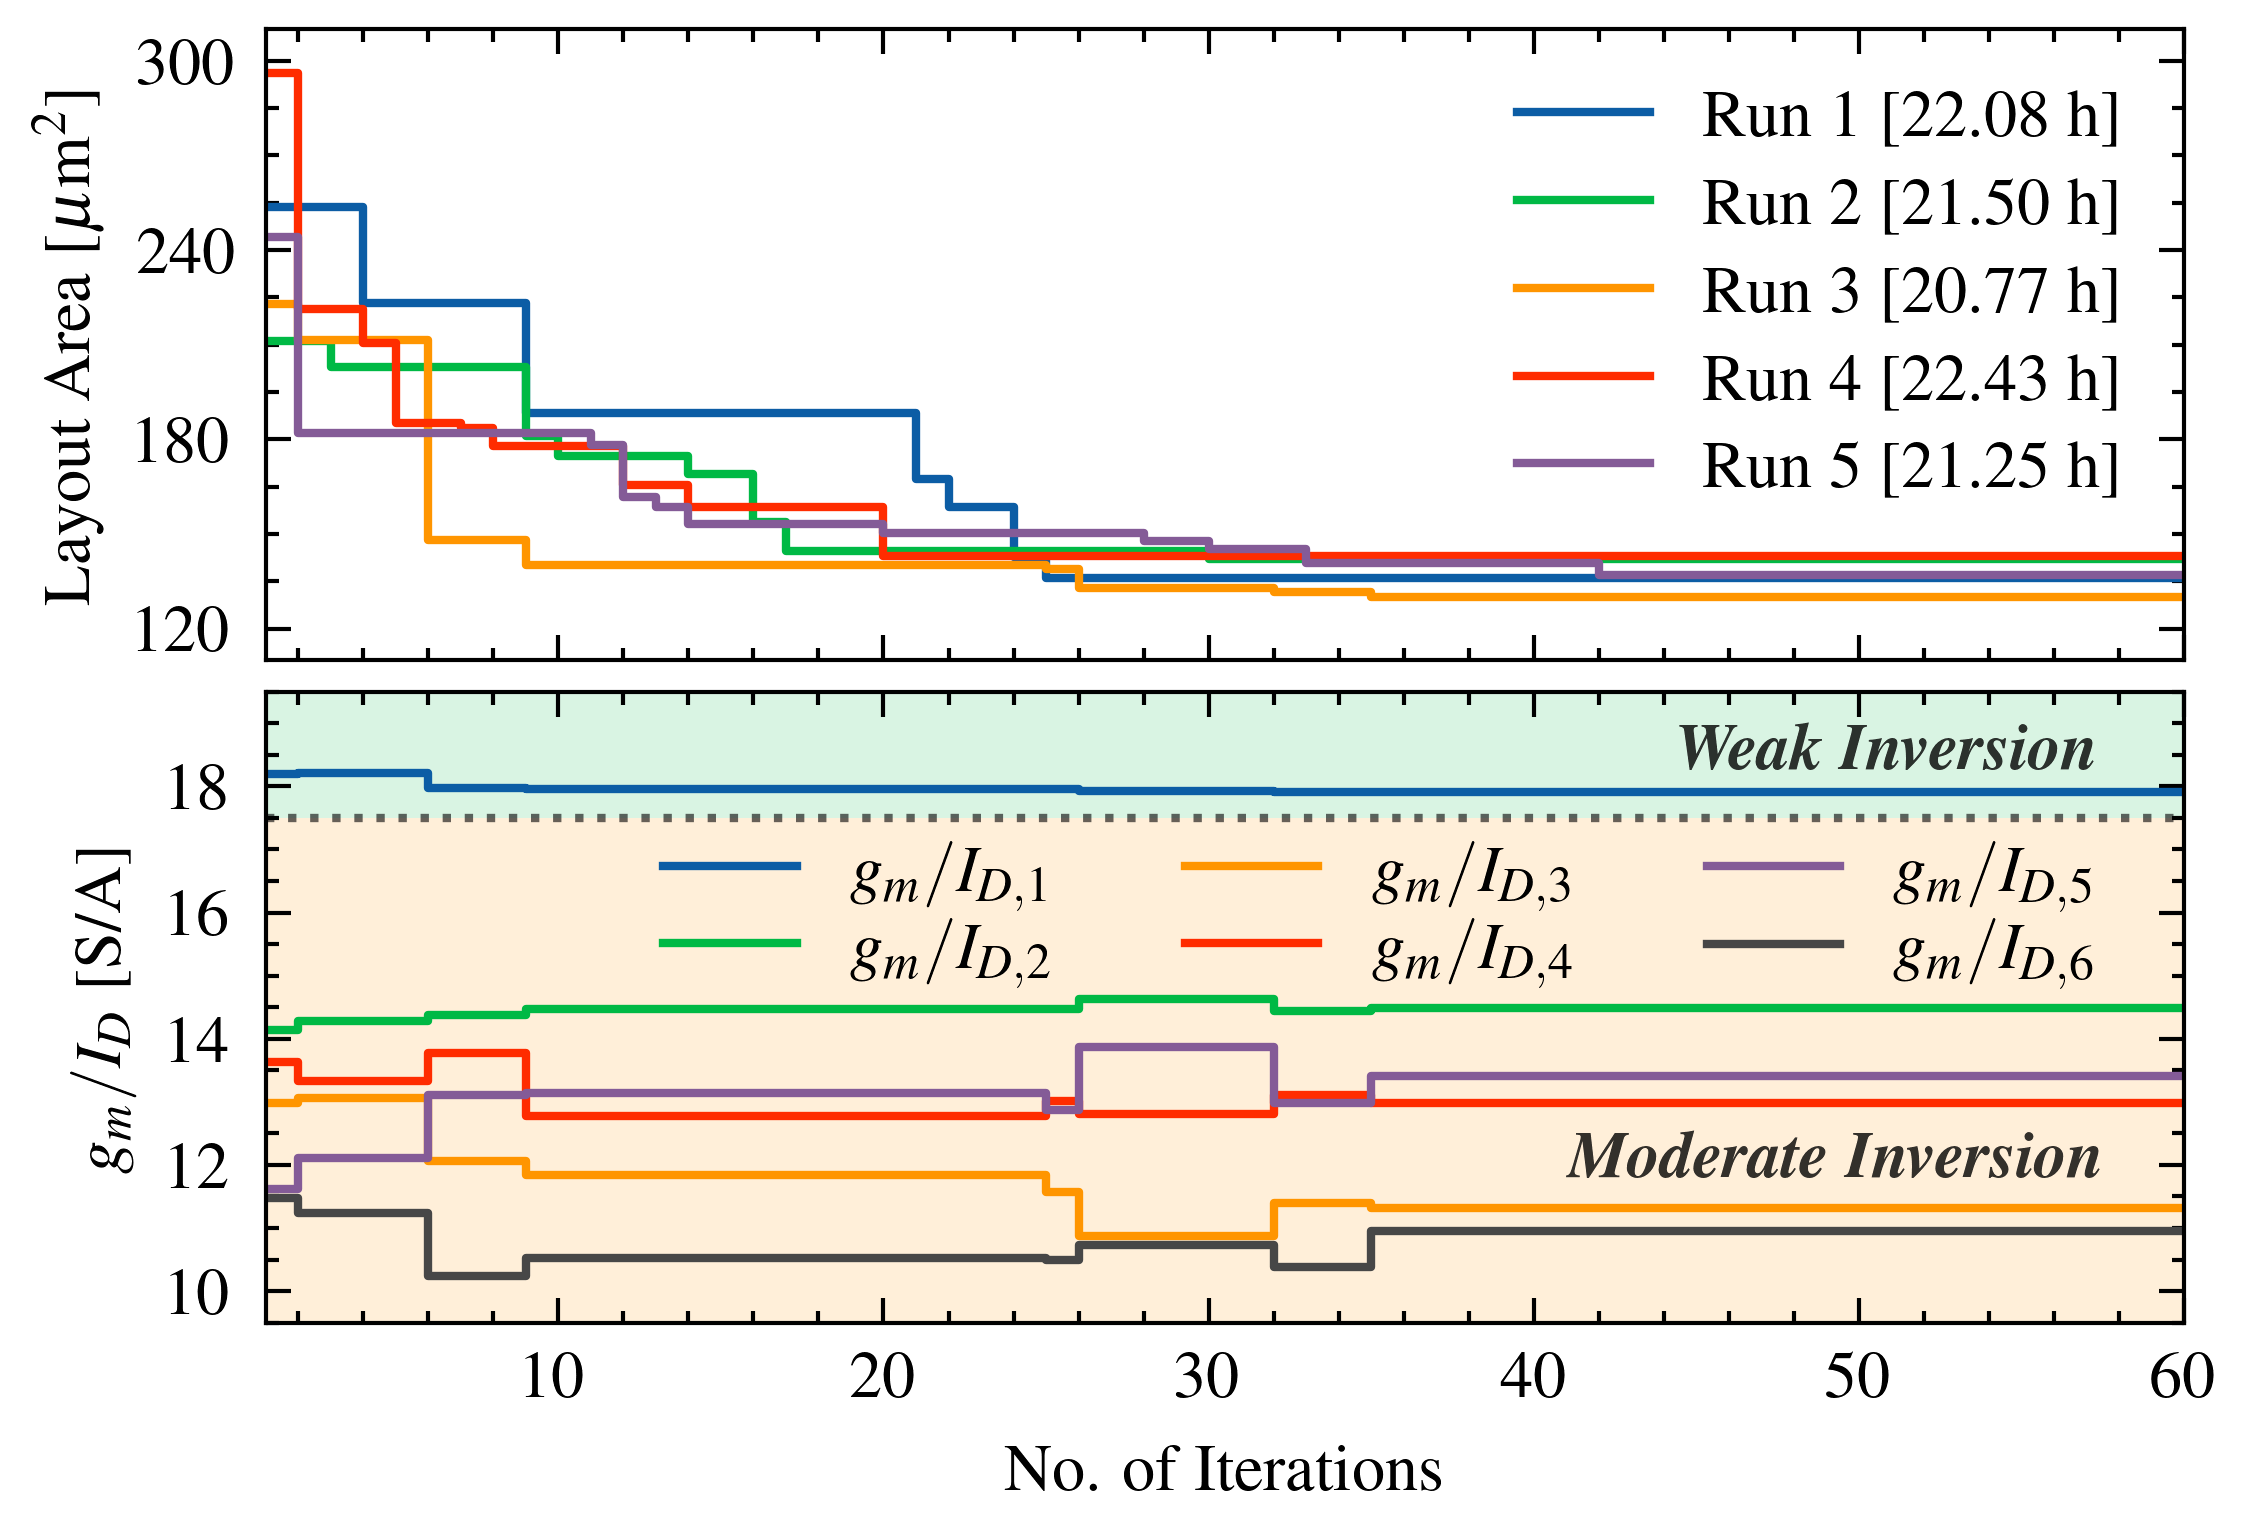

In [56]:
# Create Figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# ----- Top Subplot: Area -----
for i, data in enumerate(plot_area_data):
    area_lines.append(ax1.step(all_iterations, data, where='post', label=fr'Run {i+1} [{run_times[i]:.2f} h]'))

lns = [line[0] for line in area_lines]
ax1.legend(lns, [l.get_label() for l in lns], loc='best', labelspacing=0.4)

ax1.set_ylabel(r'Layout Area [$\mu$m$^2$]')

ax1.set_ylim(110, 310)
ax1.set_yticks([120, 180, 240, 300])

# ----- Bottom Subplot: gm/ID -----
for i, data in enumerate(plot_gmid_data):
    gmid_lines.append(ax2.step(all_iterations, data, where='post', label=fr'$g_m/I_{{D, {i+1}}}$'))

lns = [line[0] for line in gmid_lines]
ax2.legend(lns, [l.get_label() for l in lns], loc='upper right', bbox_to_anchor=(0.985, 0.86), ncol=3, labelspacing=0.1)

ax2.text(57.5, 19, r'\textbf{\textit{Weak Inversion}}', fontsize=8, ha='right', va='top', color='black', alpha=0.8)
ax2.text(57.5, 11.6, r'\textbf{\textit{Moderate Inversion}}', fontsize=8, ha='right', va='bottom', color='black', alpha=0.8)

ax2.axhspan(0, 7.5, color=ieee_colors[0], alpha=0.15, lw=0)
ax2.axhspan(7.5, 17.5, color=ieee_colors[2], alpha=0.15, lw=0)
ax2.axhspan(17.5, 30, color=ieee_colors[1], alpha=0.15, lw=0)
ax2.axhline(7.5, color='black', linestyle=':', alpha=0.6, zorder=1)
ax2.axhline(17.5, color='black', linestyle=':', alpha=0.6, zorder=1)

ax2.set_xlabel(r'No. of Iterations')
ax2.set_ylabel(r'$g_m/I_D$ [S/A]')

ax2.set_xlim(1, 60)
ax2.set_ylim(9.5, 19.5)
ax2.set_xticks([10, 20, 30, 40, 50, 60])
ax2.set_yticks([10, 12, 14, 16, 18])

# Export and Display
fig.set_figheight(2.8)
fig.set_figwidth(4.125)
fig.subplots_adjust(hspace=0.05)
plt.savefig('PSO_CONVERGENCE.pdf', format='pdf', bbox_inches='tight')
plt.show()